# Cell-type and spatial domains annotation

This notebook starts from an already pre-processed `AnnData` object (as if you already used Sopa for cell segmentation / aggretation) and uses [scConcept](https://github.com/theislab/scConcept) and [Novae](https://github.com/prism-oncology/novae) for postprocessing of a real colon cancer slide.

> ℹ️ For the sake of this workshop, we already computed embeddings so that you get started quickly. Indeed, running scConcept and Novae on this slide would loose too much time for a workshop. Of course, feel free to check their documentation to know more about their usage.


## Dependencies

We'll need `novae` and `pyarrow`. Note that we don't install `scConcept`, because we'll directly load pre-computed embeddings.


In [ ]:
!pip install novae pyarrow

## Loading pre-computed embeddings and annotations

Within `novae`, we have a function to load our public dataset used during training. We'll use this function to load one **colon cancer** slide.

> ℹ️ Below, we use `[0]` because `novae.load_dataset` returns a list of slides. Here, we selected a slide by its name, so there is only one slide anyway.


In [ ]:
import novae

adata = novae.load_dataset(
    pattern="Xenium_V1_Human_Colon_Cancer_P5_CRC_Add_on_FFPE_outs",  # directly use the slide name
    annotations=True,  # novae spatial domains annotations
    embeddings="corpus360M[multi-species]-model170M",  # name of the scConcept model
)[0]

[INFO] (novae.data._load.hf) Found 1 h5ad file(s) matching the filters.


We see the following elements in the `AnnData` object:

1. Two novae keys in `.obs` with spatial domains at different resolutions: `novae_domains_res0.8`, `novae_domains_res1`
2. `X_scConcept` embeddings in `.obsm`
3. ⚠️ Pre-computed `cell_types` and `cell_type_level1`, but we will re-compute them using the scConcept embeddings.


In [3]:
adata

AnnData object with n_obs × n_vars = 275998 × 422
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'novae_sid', 'technology', 'name', 'cell_type', 'cell_type_level1', 'novae_domains_res0.8', 'novae_domains_res1'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'log1p', 'neighbors', 'novae_tissue', 'spatial_neighbors', 'spatialdata_attrs', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'X_scConcept'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'
    layers: 'counts', None (.X)

## Cell-level embedding usage

We already have scConcept embeddings, and we want to use it to transfer cell-type annotations from a scRNAseq reference (i.e., annotated single-cell data).

To do that, we downloaded a pre-annotated colon cancer scRNAseq atlas from [CELLxGENE](https://cellxgene.cziscience.com/) and computed the corresponding scConcept embeddings. Then, we subsetted this reference to 1,000 cells for the sake of this workshop, and added it to our Hugging Face below so that you can download it easily as below.

> ℹ️ Although we use scConcept, we could use any model that produces an embedding at the cell-level. This is not the case of Novae though, since it produces an embedding that represents a cell's neighborhood, not just the actual cell. We therefore need to make the distinction between cell-level tasks (enabled by scConcept) and neighborhood-level tasks (enabled by Novae).


In [4]:
import anndata as ad
from huggingface_hub import hf_hub_download

local_path = hf_hub_download(
    repo_id="prism-oncology/sandbox",
    filename="cirm_tutorials/crc_public_ref_subsample.h5ad",
    repo_type="dataset",
)

adata_ref = ad.read_h5ad(local_path)

We have again `X_scConcept` in `.obsm`:


In [5]:
adata_ref

AnnData object with n_obs × n_vars = 1000 × 16894
    obs: 'sampleID', 'level_1_annot', 'level_2_annot', 'level_3_annot', 'n_counts', 'cell_type_ontology_term_id', 'sourceID', 'study', 'donorID_unified', 'donor_category', 'donor_disease', 'organ_unified', 'age_unified', 'sample_type', 'sample_category', 'sample_retrieval', 'tissue_fraction', 'cell_fraction_unified', 'cell_sorting', 'organ_groups', 'control_vs_disease', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'cell_type_level1', 'cell_type_level2'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'gene_ids', 'gene'
    uns: 

And cell-type annotation at three different levels:


/Users/quentinblampey/miniforge3/envs/workshop2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)
/Users/quentinblampey/miniforge3/envs/workshop2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)
/Users/quentinblampey/miniforge3/envs/workshop2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs

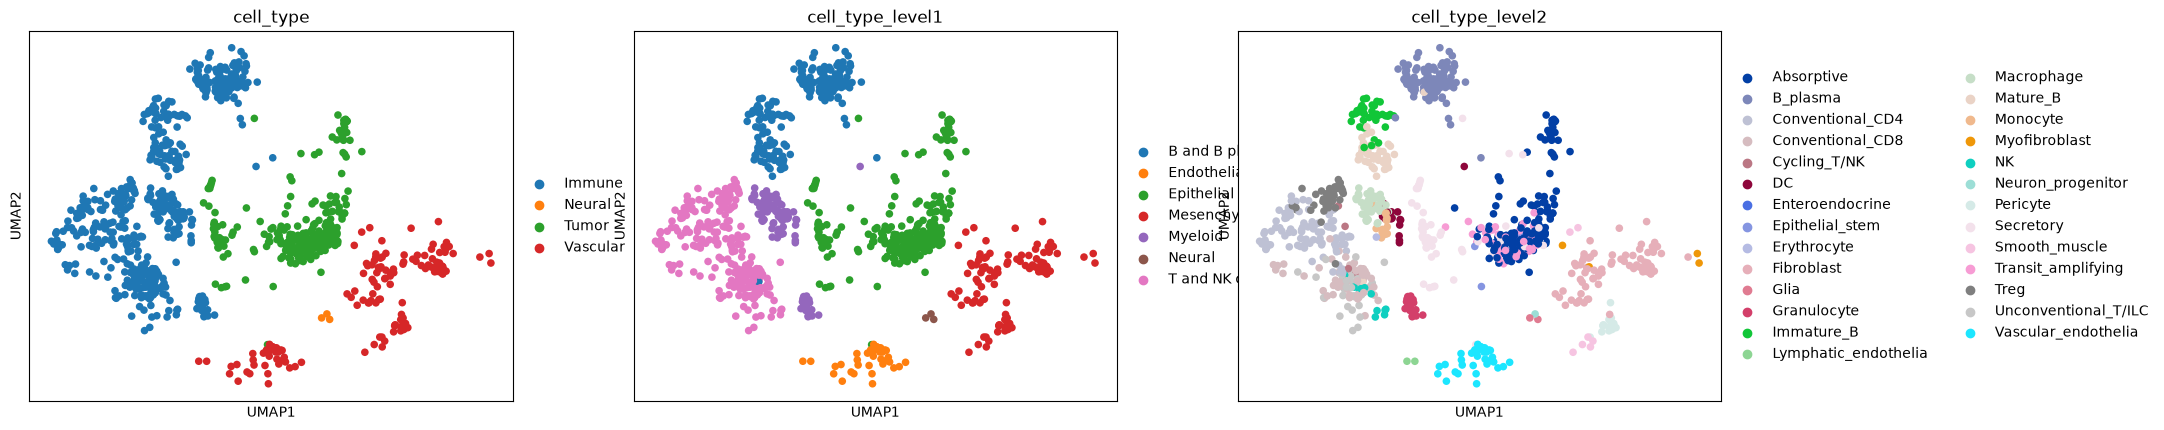

In [6]:
import scanpy as sc

sc.pl.umap(adata_ref, color=["cell_type", "cell_type_level1", "cell_type_level2"])

### Exercice A: Cell-type assignment

1. Fit a `kNN` using `sklearn` to transfer the cell-type labels of your reference `adata_ref` onto your spatial object `adata`. Apply this to each level separately.

_⚠️ *WARNING*: make sure not to overwrite the pre-computed cell-type labels in `adata`. We'll use them later to check whether your label transfer corresponds to the pre-computed labels._


In [7]:
from sklearn.neighbors import NearestNeighbors

In [ ]:
...

2. Plot a UMAP of `adata` colored by the different cell-type levels. Do you observe something interesting regarding the epithelial cells? Is the cell-type annotation clean or noisy? Why?


In [ ]:
...

3. Is the cell-type hierarchy preserved? That is, if a cell is annotated as a Fibroblast in level 1, it shouldn't be annotated as an Immune cell in level 0. If the hierarchy is not preserved, how to guarantee it?


In [ ]:
...

4. Does the label transfer depend a lot on the number of cells from the reference? Compare your labels with the pre-computed cell-type annotations. You can also subsample `adata_ref` even more to see at which number of cells it drastically reduce the assignment agreement.


In [ ]:
...

### Exercice B: gene expression inference

In the spatial `adata` object, we have only 422 genes.

1. Use a kNN to infer whole-genome expression. _Hint: for each spatial cell, you can pseudo-bulk its k-neirest-cells in the scConcept space get one expression vector. This can be performed on sparse matrices to avoid a too high RAM usage._


In [ ]:
...

2. Is it using more memory per cell than the reference dataset? Why?


In [ ]:
...

## Spatial domains

We already loaded Novae domains, we can show them spatially as below:


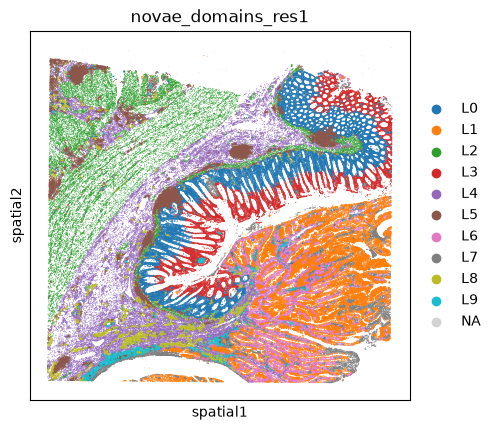

In [53]:
sc.pl.spatial(adata, color="novae_domains_res1", spot_size=15)

### Exercice C: spatial domains labeling

1. Previously, we saw that we have two subtypes of Epithelial cells. Are they located in the same niches?


In [ ]:
...

2. Extract features that describes the spatial domains, such as DEGs between domains, or cell-type percentage per domain.


In [ ]:
...

3. Based on this, try to get (coarse) labels for each domain. In particular, try to explain what's the difference between the two epithelial cell subtypes.

_Hint: if you're stuck, you can check this [Novae tutorial](https://prism-oncology.github.io/novae/tutorials/labeling/)._


In [ ]:
...

## Real usage

Here, we used pre-computed embeddings and annotations. To actually compute it on your own datasets, check the [scConcept](https://scconcept.readthedocs.io/en/latest/) and [Novae](https://prism-oncology.github.io/novae/) documentations.
